# Generate Disturbance Profile


In [48]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation

In [49]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

import new file (pls pls work)

In [54]:
case_path = andes.get_case(test_case_dir / "wscc9.xlsx")
ss_ref = andes.load(case_path)

ss_ref.PFlow.run()

gen_idxs = list(ss_ref.PV.idx.v)
gen_buses = list(ss_ref.PV.bus.v)
#M_base = ss_ref.PV.M.v.copy()

#gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
#gen_info.sort_values("M", ascending=False)


## Set Up Fault and Run TDS
Trip the synchronous generator with the highest inertia (GENROU 2) at t = 1s.  $\alpha$ (inertia scaling) set to lowest (0.15). 

In [118]:
add_idx = "PQ_1" # add a load, causing a disturbance

# inertia_scales = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15] just testing lowest
# alpha = 0.15

ss = andes.load(case_path, setup=False)
ss.add("Toggle", model="PQ", dev=add_idx, t=5.0) # add the load @ t=1s
ss.setup()
ss.config.warn_abnormal = 0
#ss.GENROU.M.v[:] = M_base

ss.PFlow.run()
ss.TDS.config.tf = 20
ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 0 # ignore stability criteria (run until end of simulation time)

ss.TDS.run()

#results = ss.TDS.get_timeseries(ss.GENROU.omega)

True

## Results

### COI Frequency

In [ ]:
# plotting
weights = M_base / M_base.sum()
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

print(results)

f_coi = (results.values * weights).sum(axis=1) * 60
ax.plot(results.index, f_coi, color="tab:blue", linewidth=1.8)

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("COI Frequency")
#ax.set_xlim(0.0, 5.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

### Nadir & RoCoF

In [ ]:
f_coi = (results.values * weights).sum(axis=1) * 60
t = results.index.values

nadir = f_coi[t > 1.0].min()

post = (t >= 1.0) & (t <= 2.0)
t_post, f_post = t[post], f_coi[post]
rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

print("Nadir: " + str(nadir))
print ("RoCoF: " + str(rocof))

### Voltages

In [119]:
voltage_df = ss.TDS.get_timeseries(ss.Bus.v)
print(f"Voltage DataFrame shape: {voltage_df.shape}")
print(f"Columns (bus indices): {list(voltage_df.columns)}")

Voltage DataFrame shape: (603, 9)
Columns (bus indices): [1, 2, 3, 4, 5, 6, 7, 8, 9]


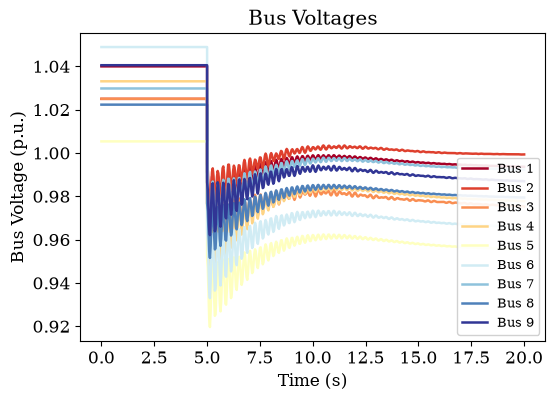

In [120]:
# Voltage at All Buses
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, bus in enumerate(voltage_df.columns):
    color = cmap(i / (len(voltage_df.columns) - 1))

    ax.plot(voltage_df.index, voltage_df[bus], color=color, linewidth=1.8,
            label=f"Bus {bus}")

#H = np.average(M_base) / 2

ax.set_xlabel("Time (s)")
ax.set_ylabel("Bus Voltage (p.u.)")
ax.set_title(f"Bus Voltages")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


In [121]:
freq_1 = ss.TDS.get_timeseries(ss.BusROCOF.f).loc[:,"BusROCOF_2"]
voltage_1 = voltage_df.loc[:,1]

In [122]:
## Export Bus 1 Voltage and Frequency
export_df = pd.concat([voltage_1, freq_1], axis=1)
export_df.columns = ["Voltage", "Frequency"]
export_df.index.name = "Time"
export_df

,Voltage,Frequency
Time,,
0.000000,1.040000,1.000000
0.033333,1.040000,1.000000
0.066667,1.040000,1.000000
0.100000,1.040000,1.000000
0.133333,1.040000,1.000000
...,...,...
19.866767,0.993659,0.986739
19.900100,0.993668,0.986745
19.933433,0.993670,0.986752


In [126]:
sim_time = ss.TDS.config.tf
export_df.to_excel(f'{disturbance_profile_dir}/disturbance_profile_wscc_{sim_time}.xlsx', index=True)

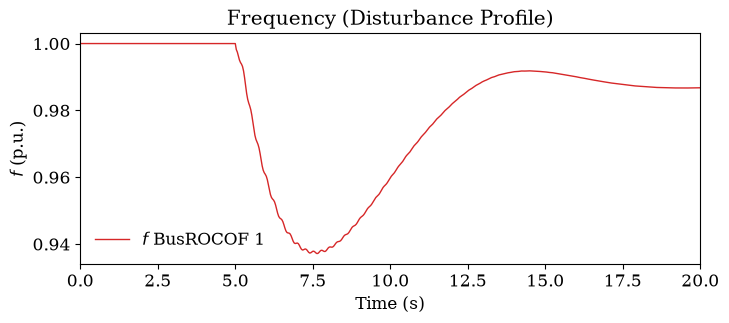

In [123]:
fig, ax = ss.TDS.plt.plot(ss.BusROCOF.f, 
                          a = 0,
                          title="Frequency (Disturbance Profile)", 
                          xlabel="Time (s)", 
                          ylabel = f"$f$ (p.u.)", 
                          color="tab:red",
                          figsize=(8, 3))

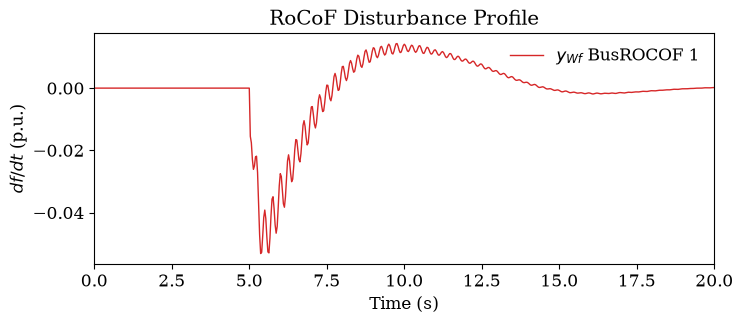

In [124]:
fig, ax = ss.TDS.plt.plot(ss.BusROCOF.Wf_y, 
                          a = 0,
                          title="RoCoF Disturbance Profile", 
                          xlabel="Time (s)", 
                          ylabel = f"$df/dt$ (p.u.)", 
                          color="tab:red",
                          figsize=(8, 3))

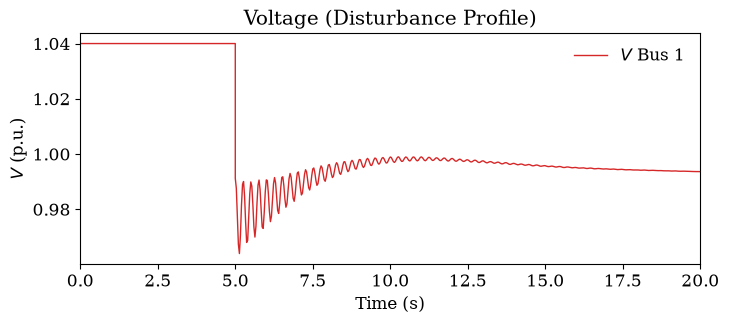

In [125]:
fig, ax = ss.TDS.plt.plot(ss.Bus.v,
                          a = 0, 
                          title="Voltage (Disturbance Profile)", 
                          xlabel="Time (s)", 
                          ylabel = f"$V$ (p.u.)", 
                          color="tab:red",
                          figsize=(8, 3))

In [ ]:
hi = ss.TDS.get_timeseries(ss.BusROCOF.f)
np.min(hi)